<a href="https://colab.research.google.com/github/Ezza2345/Plant-Disease-Detection/blob/main/Plant_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -O "dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2026-03-03 15:18:12--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2026-03-03 15:18:13--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.74.85, 3.5.69.0, 52.92.36.98, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.74.85|:443... connect

In [ ]:
!unzip /content/dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [ ]:
# Import matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt
# Import numpy for numerical operations and working with arrays
import numpy as np
# Import os module to interact with the operating system (files, directories, paths)
import os
# Import TensorFlow library for machine learning and deep learning models
import tensorflow as tf

In [ ]:
# Install the split-folders library
# This library is used to split a dataset into training, validation, and test folders easily
!pip install split-folders

In [ ]:
# Import the splitfolders library to split dataset into train, validation, and test sets
import splitfolders
splitfolders.ratio('/content/Plant_leave_diseases_dataset_with_augmentation', output="dataset", seed=1337, ratio=(.8, .1, .1))

Copying files: 61486 files [00:19, 3226.16 files/s]


Data Preprocessing


In [ ]:
# Path to training and validation datasets
train_dir = "/content/dataset/train"
validation_dir = "/content/dataset/val"
# Set batch size and image size for model input
BATCH_SIZE = 32
IMG_SIZE = (160, 160)
# Load training dataset from directory
# Images are automatically labeled based on folder names
train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,
                                                            shuffle=True,
                                                            batch_size=BATCH_SIZE,
                                                            image_size=IMG_SIZE)

Found 49179 files belonging to 39 classes.


In [ ]:
# Load validation dataset from directory
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,
                                                                 shuffle=True,
                                                                 batch_size=BATCH_SIZE,
                                                                 image_size=IMG_SIZE)
# Path to test dataset
test_dir = "/content/dataset/test"
# Load test dataset (used for final evaluation of the model)
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir,
                                                           batch_size=BATCH_SIZE,
                                                           image_size=IMG_SIZE)

Found 6139 files belonging to 39 classes.
Found 6168 files belonging to 39 classes.


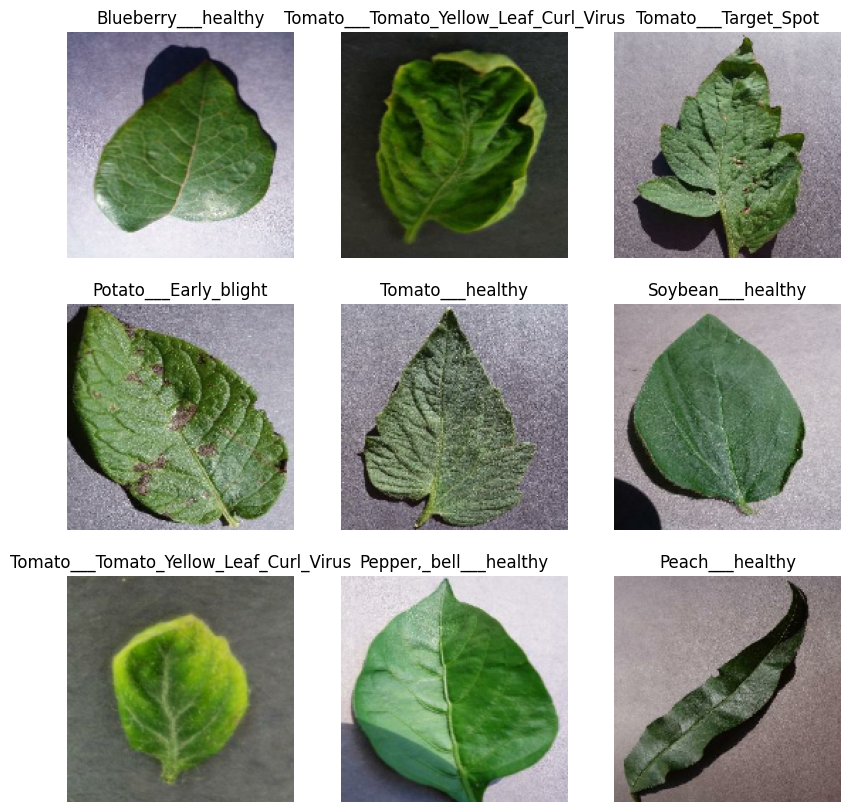

In [ ]:
# Get class names (folder names become labels)
class_names = train_dataset.class_names
# Create a figure for displaying images
plt.figure(figsize=(10, 10))
# Take one batch from training dataset
for images, labels in train_dataset.take(1):
   # Display first 9 images from the batch
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    # Show image
    plt.imshow(images[i].numpy().astype("uint8"))
       # Show corresponding label name
    plt.title(class_names[labels[i]])
# Hide axis
    plt.axis("off")

In [ ]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Background_without_leaves',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot'

In [ ]:
# Enable automatic performance optimization for dataset loading
AUTOTUNE = tf.data.AUTOTUNE
# Improve performance by prefetching data while model is training
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Preprocessing function for EfficientNet model input format
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

Create the base model from the pre-trained convnets


In [ ]:
# Define full image shape (height, width, channels)
IMG_SHAPE = IMG_SIZE + (3,)
# Load pre-trained EfficientNetB4 model without the top classification layer
base_model = tf.keras.applications.EfficientNetB4(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet',

)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Get one batch of images and labels from training dataset
image_batch, label_batch = next(iter(train_dataset))
# Pass images through base model to extract features
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1792)


Feature Extraction

In [ ]:
# Freeze base model so its weights are not trained
base_model.trainable = False

In [ ]:
base_model.summary()

Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 160, 160,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 160, 160,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 160, 160,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 161, 161,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 80, 80,    │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 80, 80,    │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 80, 80,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 80, 80,    │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 80, 80,    │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 80, 80,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 80, 80,    │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 80, 80,    │      1,152 │ block1a_se_excit

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
# Add global average pooling to reduce feature map size
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1792)


In [ ]:
# Final dense layer for classification (one output per class)
prediction_layer = tf.keras.layers.Dense(len(class_names), activation='sigmoid')
# Get predictions for the batch
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)

(32, 39)


In [ ]:
# Define input layer with image shape
inputs = tf.keras.Input(shape=(160, 160, 3))
# Apply EfficientNet preprocessing
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
# Create the full model
model = tf.keras.Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743,750 (67.69 MB)

 Trainable params: 69,927 (273.15 KB)

 Non-trainable params: 17,673,823 (67.42 MB)

In [ ]:
# Check how many variables (weights) in the model are trainable
len(model.trainable_variables)

2

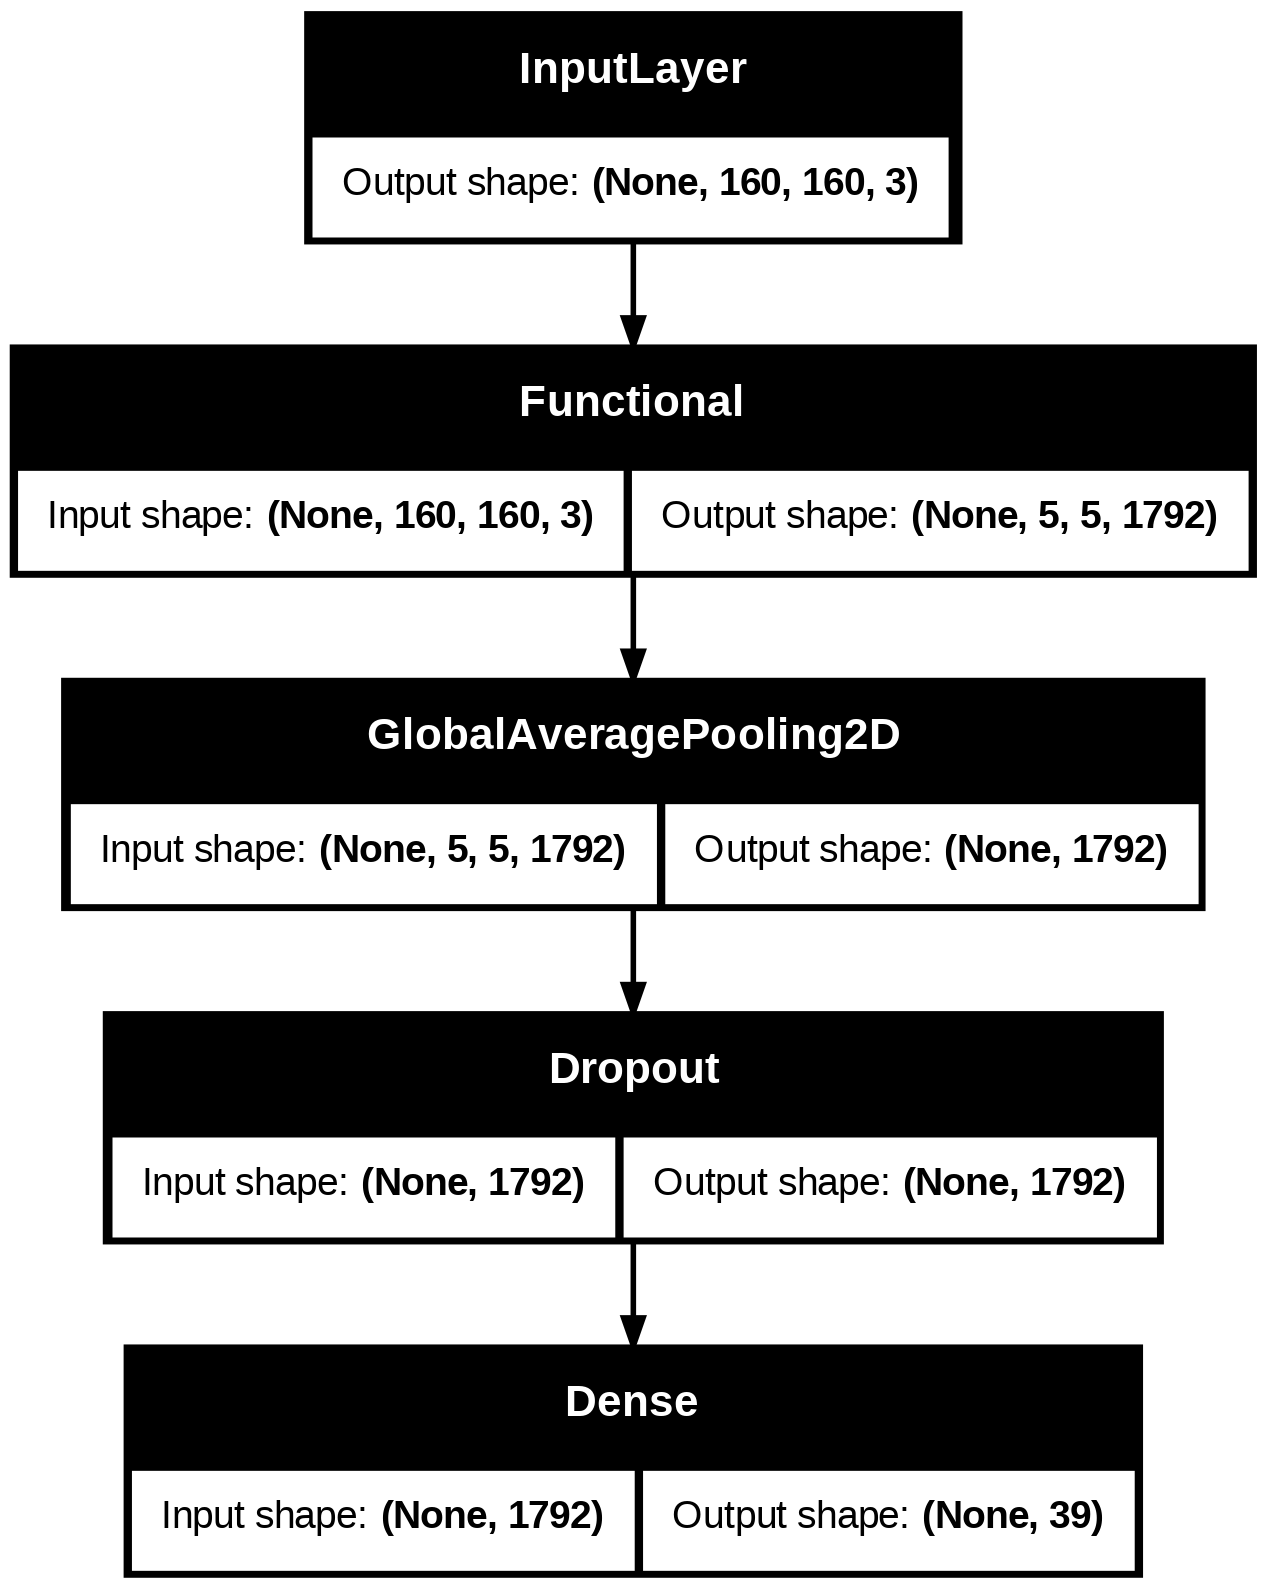

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# Compile the model with optimizer, loss function, and evaluation metric
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [ ]:
# Set number of initial training epochs
initial_epochs = 6
# Evaluate model performance on validation dataset before training
loss0, accuracy0 = model.evaluate(validation_dataset)

192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9522 - loss: 0.1558


In [ ]:
# Print initial loss before training
print("initial loss: {:.2f}".format(loss0))
# Print initial accuracy before training
print("initial accuracy: {:.2f}".format(accuracy0))

initial loss: 0.16
initial accuracy: 0.95


In [ ]:
# Train the model
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 197s 97ms/step - accuracy: 0.9391 - loss: 0.1928 - val_accuracy: 0.9523 - val_loss: 0.1471
Epoch 2/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 102s 66ms/step - accuracy: 0.9452 - loss: 0.1764 - val_accuracy: 0.9541 - val_loss: 0.1426
Epoch 3/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 100s 65ms/step - accuracy: 0.9448 - loss: 0.1719 - val_accuracy: 0.9554 - val_loss: 0.1352
Epoch 4/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 99s 64ms/step - accuracy: 0.9457 - loss: 0.1630 - val_accuracy: 0.9536 - val_loss: 0.1353
Epoch 5/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 102s 66ms/step - accuracy: 0.9452 - loss: 0.1612 - val_accuracy: 0.9565 - val_loss: 0.1275
Epoch 6/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 98s 64ms/step - accuracy: 0.9478 - loss: 0.1549 - val_accuracy: 0.9578 - val_loss: 0.1213


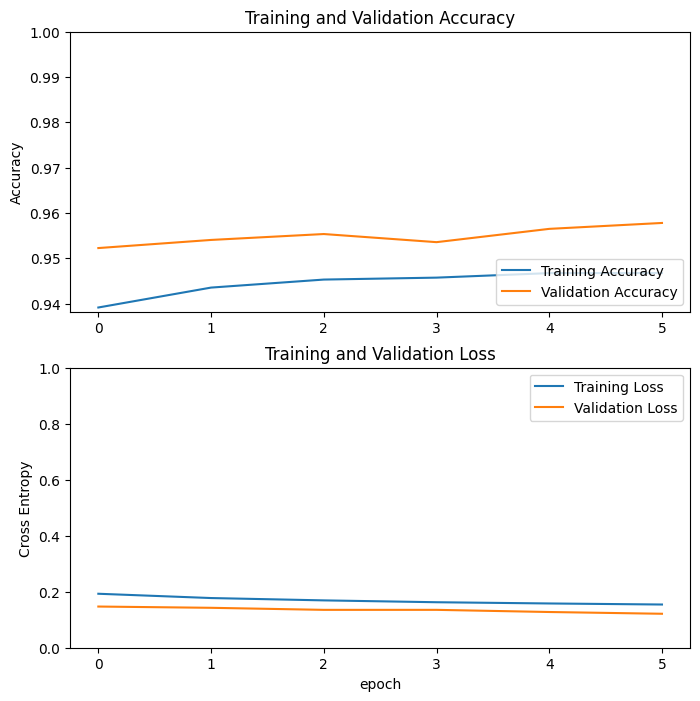

In [ ]:
# Get training and validation accuracy from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Get training and validation loss from history
loss = history.history['loss']
val_loss = history.history['val_loss']
# Create figure for plots
plt.figure(figsize=(8, 8))
# Plot accuracy graph
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')
# Plot loss graph
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
# Show both plots
plt.show()

Fine Tuning

In [ ]:
base_model.trainable = True

In [ ]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  475


In [ ]:
# Compile the model again after setting fine-tuning layers
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,743,750 (67.69 MB)

 Trainable params: 17,531,783 (66.88 MB)

 Non-trainable params: 211,967 (828.00 KB)

In [ ]:
len(model.trainable_variables)

333

In [ ]:
# Set number of fine-tuning epochs
fine_tune_epochs = 10
# Total training epochs (initial + fine-tuning)
total_epochs =  initial_epochs + fine_tune_epochs
# Continue training the model with fine-tuning
history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=validation_dataset)

Epoch 7/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 484s 228ms/step - accuracy: 0.8758 - loss: 0.4513 - val_accuracy: 0.9625 - val_loss: 0.0870
Epoch 8/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 259s 168ms/step - accuracy: 0.9636 - loss: 0.0982 - val_accuracy: 0.9661 - val_loss: 0.0533
Epoch 9/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 256s 167ms/step - accuracy: 0.9656 - loss: 0.0810 - val_accuracy: 0.9430 - val_loss: 0.1519
Epoch 10/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 257s 167ms/step - accuracy: 0.9647 - loss: 0.0654 - val_accuracy: 0.9523 - val_loss: 0.0711
Epoch 11/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 268s 174ms/step - accuracy: 0.9699 - loss: 0.0531 - val_accuracy: 0.9480 - val_loss: 0.0779
Epoch 12/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 263s 171ms/step - accuracy: 0.9698 - loss: 0.0521 - val_accuracy: 0.9658 - val_loss: 0.0438
Epoch 13/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 268s 174ms/step - accuracy: 0.9678 - loss: 0.0389 - val_accuracy: 0.9578 - val_loss: 0.0504
Epoch 14/16
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 269s 175ms/step

In [ ]:
# Combine initial and fine-tuning accuracy results
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
# Combine initial and fine-tuning loss results
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

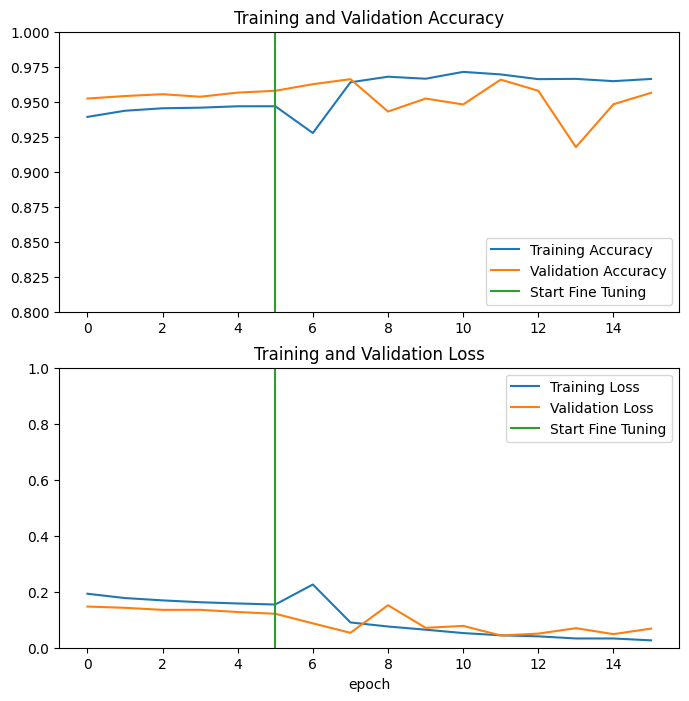

In [ ]:
# Create figure for plots
plt.figure(figsize=(8, 8))
# Plot accuracy
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
# Mark start of fine-tuning
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
# Plot loss
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
# Mark start of fine-tuning
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
# Evaluate the final model on the test dataset
loss, accuracy = model.evaluate(test_dataset)
# Print test accuracy
print('Test accuracy :', accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 30s 156ms/step - accuracy: 0.9509 - loss: 0.0559
Test accuracy : 0.9565499424934387


Predictions:
 [24 36 16 25 16 34 34  1 18 38 13 25 34 38 16 10 17 25 32 31 17 16 16 33
 15 25 15 16 29 16 17  8]
Labels:
 [24 36 16 25 16 34 34  1 18 38 13 25 34 38 16 10 17 25 32 31 17 16 16 33
 15 25 15 16 29 16 17  8]


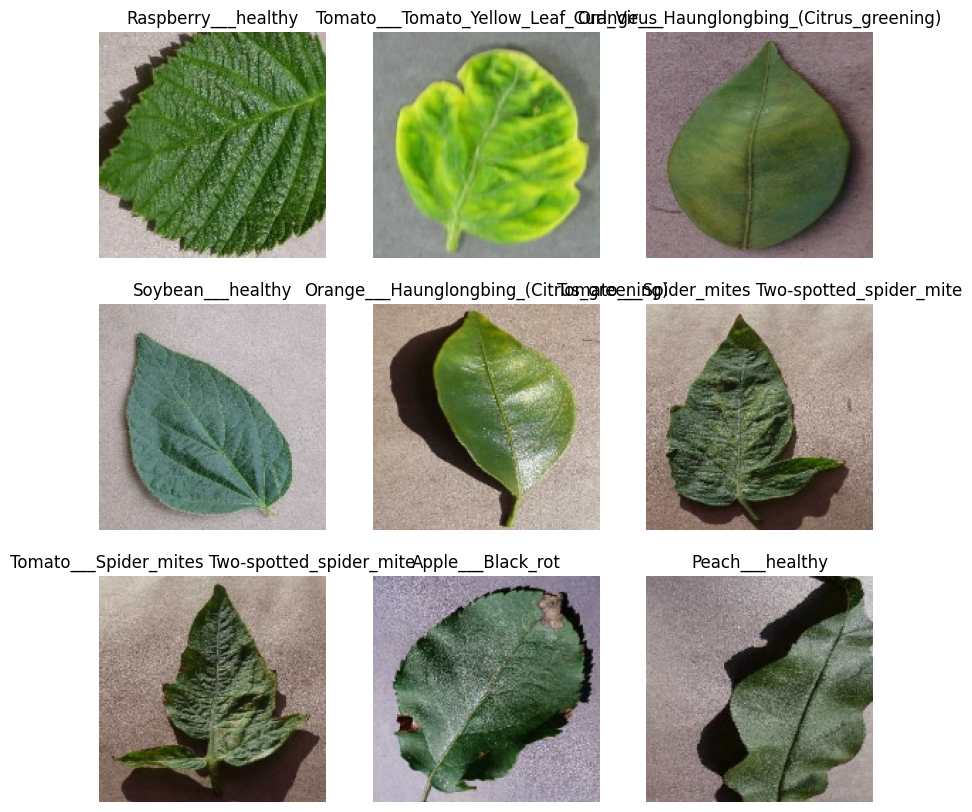

Saving Model

In [ ]:
model.save("plant_disease_recog_model_pwp.keras")